In [1]:
import sys
import os
import gc
import time
import random
import re
from tqdm import tqdm 
import json
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM, LlamaTokenizer, LlamaForCausalLM, BatchEncoding
import matplotlib.pyplot as plt
from math import ceil
from sentence_transformers import SentenceTransformer
from datetime import datetime
from math import sqrt
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
sys.path.append("/coc/pskynet6/dhe83/mice/src")
import config
import utils
from prompts import *

In [2]:
tasks = ["COPA"]
val = {}
for task_name in tasks:
    path = os.path.join("/nethome/dhe83/mice/data", task_name)
    task = utils.read_jsonl(os.path.join(path, "val.jsonl"))
    print(task_name)
    task = {x['idx']: x for x in task}
    val[task_name] = task

COPA


In [4]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large", device_map="auto")

Downloading:   0%|          | 0.00/792k [00:00<?, ?B/s]

Downloading: 0.00B [00:00, ?B/s]

Downloading: 0.00B [00:00, ?B/s]

Downloading:   0%|          | 0.00/662 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [2]:
model_addr = "decapoda-research/llama-7b-hf"
tokenizer = LlamaTokenizer.from_pretrained(model_addr, use_fast=False, padding_side='left')
model = LlamaForCausalLM.from_pretrained(
    model_addr,
    load_in_8bit=True,
#     torch_dtype=torch.float16,
    device_map='auto'
)
# unwind broken decapoda-research config
model.config.pad_token_id = tokenizer.pad_token_id = 0  # unk
model.config.bos_token_id = 1
model.config.eos_token_id = 2
if torch.__version__ >= "2" and sys.platform != "win32":
    model = torch.compile(model)
print("done!")

normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.
Overriding torch_dtype=None with `torch_dtype=torch.float16` due to requirements of `bitsandbytes` to enable model loading in mixed int8. Either pass torch_dtype=torch.float16 or don't pass this argument at all to remove this warning.



===================================BUG REPORT===================================
Welcome to bitsandbytes. For bug reports, please run

python -m bitsandbytes

 and submit this information together with your error trace to: https://github.com/TimDettmers/bitsandbytes/issues
bin /srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/python3.9/site-packages/bitsandbytes/libbitsandbytes_cuda117.so
CUDA SETUP: CUDA runtime path found: /srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/libcudart.so
CUDA SETUP: Highest compute capability among GPUs detected: 8.6
CUDA SETUP: Detected CUDA version 117
CUDA SETUP: Loading binary /srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/python3.9/site-packages/bitsandbytes/libbitsandbytes_cuda117.so...


/srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/python3.9/site-packages/bitsandbytes/cuda_setup/main.py:145: UserWarning: Found duplicate ['libcudart.so', 'libcudart.so.11.0', 'libcudart.so.12.0'] files: {PosixPath('/srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/libcudart.so'), PosixPath('/srv/nlprx-lab/share6/dhe83/miniconda3/envs/mice/lib/libcudart.so.11.0')}.. We'll flip a coin and try one of these, in order to fail forward.
Either way, this might cause trouble in the future:
If you get `CUDA error: invalid device function` errors, the above might be the cause and the solution is to make sure only one ['libcudart.so', 'libcudart.so.11.0', 'libcudart.so.12.0'] in the paths that we search based on your env.
  warn(msg)


Loading checkpoint shards:   0%|          | 0/33 [00:00<?, ?it/s]

done!


In [8]:
def format_COPA(ex: dict)->str():
    substitutions = {"cause": "because", "effect": "so"}
    return [f"{ex['premise'][:-1]} {substitutions[ex['question']]} {ans.lower()}" 
            for ans in [ex['choice1'], ex['choice2']]]

In [9]:
logs = {}
preds = {}

In [10]:
prompts = []
for index, ex in val["COPA"].items():
    prompt = format_COPA(ex)
    prompts.extend(prompt)

In [11]:
with torch.no_grad():
    tokens = tokenizer(prompts, return_tensors="pt", padding=True)
    output = model(**tokens)

    normalized = output.logits.float().log_softmax(-1)
    masked_logits = normalized * tokens.attention_mask.unsqueeze(-1)

    indices = tokens.input_ids[:,1:].unsqueeze(dim=-1)
    c = masked_logits.gather(dim=-1, index=indices)

    l = c.squeeze(-1).sum(-1)
    l = l.view(-1, 2)

ValueError: You have to specify either decoder_input_ids or decoder_inputs_embeds

In [ ]:
batch_preds = l.argmax(-1)

# Chain of Thought

In [3]:
from datasets import load_dataset
gsm8k = load_dataset("gsm8k","main")

def get_label(ex):
    return ex['answer'].split("####")[-1].strip()

def format_example(ex, in_context=False):
    prompt = f"Q: {ex['question']}\n\nA:"
    
    if in_context:
        prompt = " ".join([prompt, ex['answer']])
        prompt = re.sub("(<<).*?(>>)", "", prompt)
        prompt = re.sub("\\n(#+).*", f" The answer is {get_label(ex)}.", prompt)
    return prompt

def extract(output, in_context=False):
    answer = output.lower()
    answer = re.split("the answer is", answer)
    if len(answer) > 1:
        answer = answer[1] 
    else:
        return "" 
    answer = re.findall("\d+", answer)
    
    if len(answer) > 0:
        return answer[0] 
    else:
        return "" 

def format_few_shot(demonstrations, test):
    return "\n\n".join([*[format_example(ex, True) for ex in demonstrations], format_example(test)])

Found cached dataset gsm8k (/nethome/dhe83/.cache/huggingface/datasets/gsm8k/main/1.1.0/37bfb08b1d4fcbb01f06b03d9e1ef5f1fcbd4d3af3d08842c50d7305091285ba)


  0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
def score(prompts):        
    tokens = tokenizer(prompts, return_tensors="pt", padding=True)
    with torch.no_grad():
        output = model(**tokens)

    normalized = output.logits.float().log_softmax(-1)
    masked_logits = normalized * tokens.attention_mask.unsqueeze(-1)

    indices = tokens.input_ids[:,1:].unsqueeze(dim=-1)
    token_probs = masked_logits.gather(dim=-1, index=indices)

    log_prob = token_probs.squeeze(-1).sum(-1)
    return log_prob

In [31]:
questions, answers = [], []

In [32]:
n = 100
for x in gsm8k['train']:
    questions.append(format_example(x))
    answers.append(format_example(x, True))
    n-=1
    if n == 0: break

In [38]:
stats = []
for q, a in tqdm(zip(questions, answers), total=len(questions)):
    q_len = tokenizer(q, return_tensors="pt", padding=True).input_ids.shape[1]
    full_len = tokenizer(a, return_tensors="pt", padding=True).input_ids.shape[1]
    a_len = full_len - q_len
    
    scores = score([q, a])
    diff = (scores[1] - scores[0]).item()
    stats.append((scores, diff, a_len, diff/a_len))

100%|███████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.86it/s]


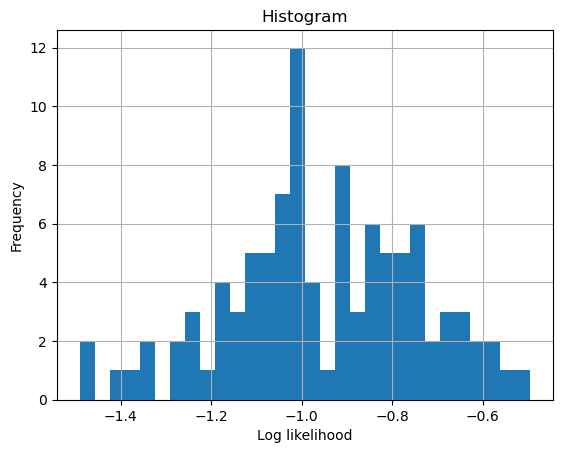

In [40]:
plt.hist([x[3] for x in stats], bins=30)  # Use 30 bins for the histogram

plt.xlabel('Log likelihood')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.grid(True)

plt.show()

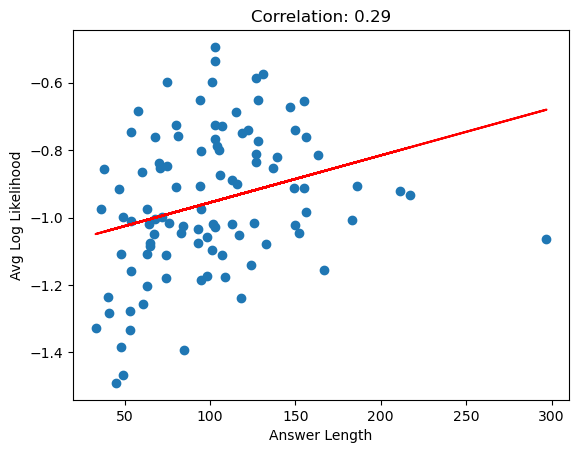

In [53]:
x = [x[2] for x in stats]  # Variable x
x = np.array(x)
y = [x[3].item() for x in stats] # Variable y

# Calculate the correlation coefficient
correlation = np.corrcoef(x, y)[0, 1]

# Calculate the slope (m) and intercept (b) of the regression line
m, b = np.polyfit(x, y, 1)

# Create a scatter plot
plt.scatter(x, y)

# Plot the regression line
plt.plot(x, m*x + b, color='red')

# Add labels and title
plt.xlabel('Answer Length')
plt.ylabel('Avg Log Likelihood')
plt.title(f'Correlation: {correlation:.2f}')
plt.show()

In [55]:
torch.exp(torch.tensor([-1]))

tensor([0.3679])

In [63]:
info = []

In [64]:
for a, p in zip(answers, [x[3] for x in stats]):
    info.append((a, p.item()))

In [66]:
info.sort(key=lambda x: x[1], reverse=True)

In [69]:
for text, prob in info:
    print(text)
    print(prob)
    print('#'*10)

Q: It's Ava's birthday party. Her parents bought a unicorn piñata for $13 and filled it with all of her favorite treats. They bought 4 bags of Reese's for $9 per bag, 3 bags of Snickers for $5 per bag, and 5 bags of Skittles for $7 per bag. How much did the unicorn piñata and the treats cost altogether?

A: The four bags of Reese's cost $9 x 4 = $36.
The three bags of Snickers cost $5 x 3 = $15.
The five bags of Skittles cost $7 x 5 = $35.
Therefore, the unicorn piñata and the treats cost $13 + $36 + $15 + $35 = $99. The answer is 99.
-0.49412181973457336
##########
Q: Dale and Andrew had breakfast at a cafe. A slice of toast costs £1, and eggs cost £3 each. Dale had 2 slices of toast and 2 eggs. Andrew had 1 slice of toast and 2 eggs. How much did their breakfast cost?

A: The cost of Dale's toast is 2 × $1 = $2.
The cost of Andrew's toast is 1 × $1 = $1.
The cost of Dale's eggs is 2 × $3 = $6.
The cost of Andrew's eggs is 2 × $3 = $6.
Their breakfast cost $2 + $1 + $6 + $6 = $15. The

In [70]:
stats

[(tensor([-121.9652, -164.9890]), tensor(-43.0239), 47, tensor(-0.9154)),
 (tensor([-112.5707, -165.7159]), tensor(-53.1452), 48, tensor(-1.1072)),
 (tensor([-157.7874, -244.9542]), tensor(-87.1669), 74, tensor(-1.1779)),
 (tensor([-127.9294, -231.4499]), tensor(-103.5205), 98, tensor(-1.0563)),
 (tensor([-103.8496, -174.5918]), tensor(-70.7422), 53, tensor(-1.3348)),
 (tensor([-179.0046, -307.2261]), tensor(-128.2215), 126, tensor(-1.0176)),
 (tensor([-141.2169, -213.0302]), tensor(-71.8133), 72, tensor(-0.9974)),
 (tensor([-254.2986, -333.3241]), tensor(-79.0255), 103, tensor(-0.7672)),
 (tensor([-227.2396, -327.5174]), tensor(-100.2778), 113, tensor(-0.8874)),
 (tensor([-166.0787, -481.8982]), tensor(-315.8195), 297, tensor(-1.0634)),
 (tensor([-222.4137, -339.1930]), tensor(-116.7793), 137, tensor(-0.8524)),
 (tensor([-213.4311, -336.5679]), tensor(-123.1367), 117, tensor(-1.0525)),
 (tensor([-108.6717, -190.8949]), tensor(-82.2232), 74, tensor(-1.1111)),
 (tensor([-179.5475, -238.